In [3]:
import matplotlib
import matplotlib.pyplot as plt

import numpy as np
import os
path = os.getcwd()

from neurolib.models.c import Model_c
import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost
from neurolib.utils import plotFunctions as plotFunc
from neurolib.models import jacobian_aln as jac_aln
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [36]:
a = Model_c()
dur_pre = 0.
dur_post = 0.

c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

max_it = 1
tol = 1e-30
incl_step = int(1. + a.params.duration/a.params.dt)
test_step = 1e-12

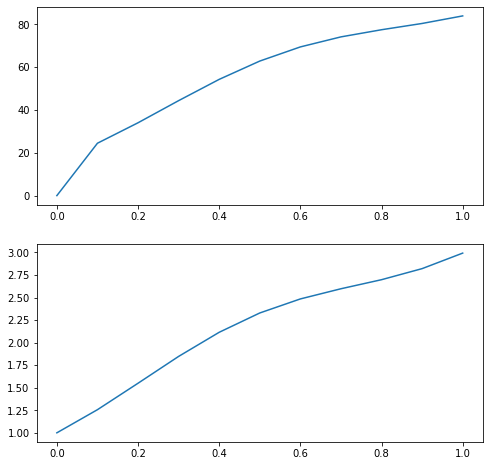

In [56]:
dur = 1.

a.params.duration = dur

target = a.getZeroTarget()
control1 = a.getZeroControl()

control1[0,0,:] += 2.
control1[0,0,:] += np.sin(6.*np.arange(0,dur+a.params.dt,a.params.dt))

a.run(control=control1)

target[:,0,:] = a.rates_exc[:,:]

fig, axes = plt.subplots(2, figsize=(8, 8))
axes[0].plot(a.t, a.state["rates_exc"][0,:])
axes[1].plot(a.t, a.state["mufe"][0,:])
#axes[2].plot(simp.t, simp.state["tau_exc"][0,:])

In [69]:
max_cntrl = 10. * 5.
start_step = 10.
cost_params = [1.0, 2.0, 0.0]

init_state_vars = np.array( [a.params.rates_exc_init, a.params.mufe_init] )
cost.setParams(cost_params[0], cost_params[1], cost_params[2])

control2 = a.getZeroControl()
#control2 += 1.

max_it = 150

A1_bestControlA, A1_bestStateA, A1_costA, runtime = a.A1(control2, target, c_scheme, u_mat, u_scheme,
        max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
        t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)

#0.7262797905237487

set cost params
RUN  0 , total integrated cost =  840.90493324178
change bisection factor to  1.04
RUN  1 , total integrated cost =  4.418591693113141
change bisection factor to  1.04
RUN  2 , total integrated cost =  4.2826309552837865
change bisection factor to  1.04
RUN  3 , total integrated cost =  4.246918644536772
change bisection factor to  1.04
RUN  4 , total integrated cost =  4.223290944928611
change bisection factor to  1.04
RUN  5 , total integrated cost =  4.207661480468532
change bisection factor to  1.04
RUN  6 , total integrated cost =  4.194614222874056
change bisection factor to  1.04
RUN  7 , total integrated cost =  4.184710230267813
change bisection factor to  1.04
RUN  8 , total integrated cost =  4.176270380039594
change bisection factor to  1.04
RUN  9 , total integrated cost =  4.169866610638698
change bisection factor to  1.04
RUN  10 , total integrated cost =  4.163937986572293
change bisection factor to  1.04
RUN  11 , total integrated cost =  4.159872872350

[[[0.         2.60811324 2.89256308 2.91564393 2.62763669 2.1263107
   1.58423326 1.18279564 1.03163338 0.99208105 0.        ]]]


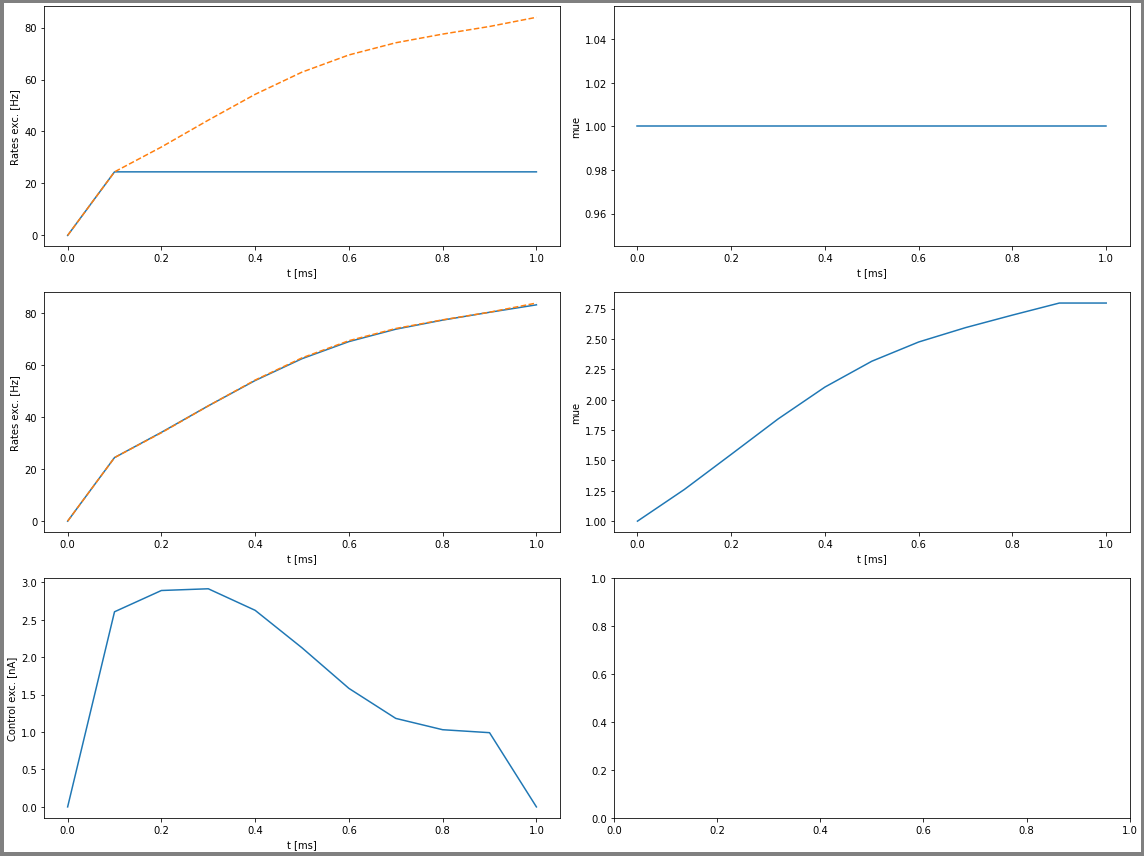

In [58]:
print(A1_bestControlA)
plotFunc.plot_control(a, A1_bestControlA, dur, dur_pre, dur_post, init_state_vars, target,
                      path, filename_ = 'simp')

In [62]:
control3 = control2.copy()
control3[:,:,0] = A1_bestControlA[:,:,0]
control3[:,:,-1] = A1_bestControlA[:,:,-1]

max_it = 60

A2_bestControlA, A2_bestStateA, A2_costA, A2_runtimeA = a.A2(control3, target, max_iteration_ = max_it,
        tolerance_ = tol, include_timestep_ = incl_step, start_step_ = start_step, test_step_ = test_step,
        max_control_ = max_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)

start ind =  1
RUN  0 , total integrated cost:  840.90493324178
Using initial step.
RUN  1 , total integrated cost:  97.42682998034044
RUN  2 , total integrated cost:  33.336704906012415
RUN  3 , total integrated cost:  13.08204584558754
RUN  4 , total integrated cost:  6.91644479536894
RUN  5 , total integrated cost:  5.1169012008819275
RUN  6 , total integrated cost:  4.627794393580216
RUN  7 , total integrated cost:  4.48828399900836
RUN  8 , total integrated cost:  4.420572303304475
change helped, counter =  1
RUN  9 , total integrated cost:  4.364650271448147
RUN  10 , total integrated cost:  4.312559754527431
change helped, counter =  1
RUN  11 , total integrated cost:  4.266555006864493
change helped, counter =  1
RUN  12 , total integrated cost:  4.229344176416733
change helped, counter =  1
RUN  13 , total integrated cost:  4.201836184452583
change helped, counter =  2
RUN  14 , total integrated cost:  4.182449406625858
change helped, counter =  1
RUN  15 , total integrated co

[[[0.         2.6103049  2.88990456 2.9152448  2.62805642 2.1266055
   1.5843756  1.18318006 1.03040251 0.99354861 0.        ]]]


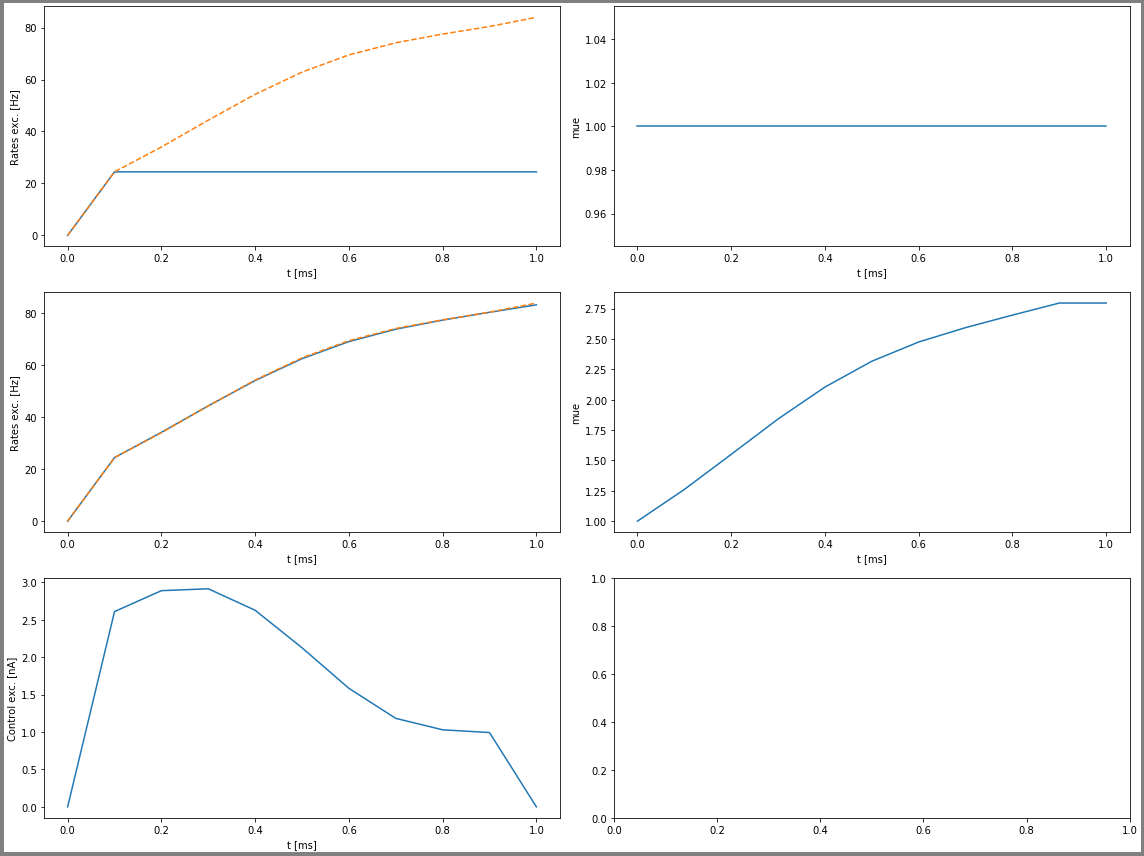

In [60]:
print(A2_bestControlA)
plotFunc.plot_control(a, A2_bestControlA, dur, dur_pre, dur_post, init_state_vars, target,
                      path, filename_ = 'a2simp')

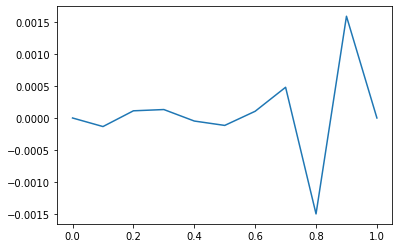

In [68]:
diff = A2_bestControlA[0,0,:] - A1_bestControlA[0,0,:]

plt.plot(a.t, diff)
plt.show()

(350, 64, 2)


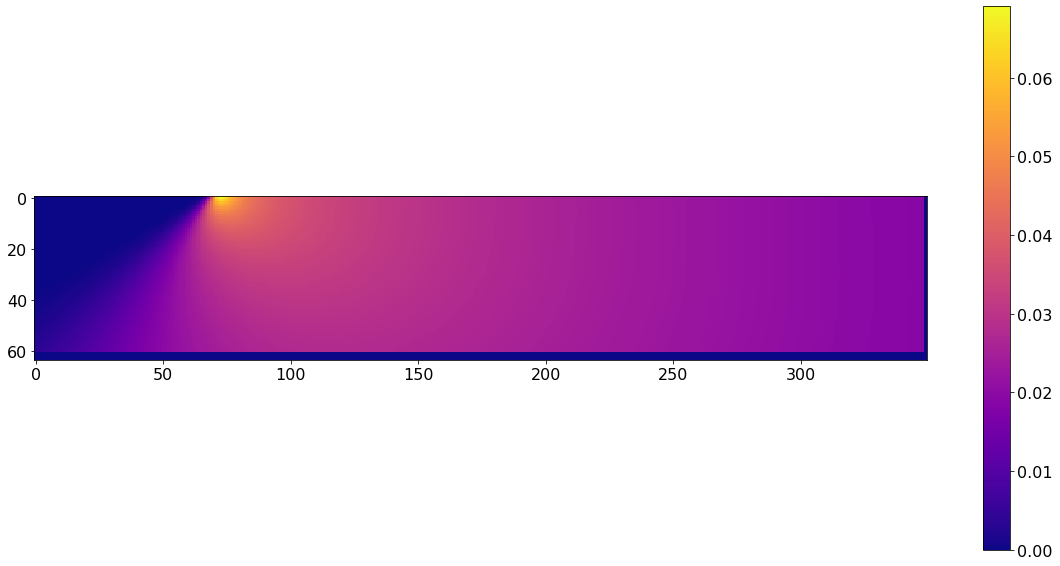

In [332]:
gradient_r = np.zeros(( len(aln.params.Irange), len(aln.params.sigmarange), 2 ))

sigma = aln.params.sigmarange[0]
mu = aln.params.Irange[0]

for sigma in range(len(aln.params.sigmarange)-3):
    for mu in range(len(aln.params.Irange)-1):
        res0 = jac_aln.der_mu(aln, aln.params.sigmarange[sigma], aln.params.Irange[mu], 0, aln.params.precalc_r)
        res1 = jac_aln.der_sigma(aln, aln.params.sigmarange[sigma], aln.params.Irange[mu], 0, aln.params.precalc_r)
        gradient_r[mu, sigma, 0] = res0
        gradient_r[mu, sigma, 1] = res1
        


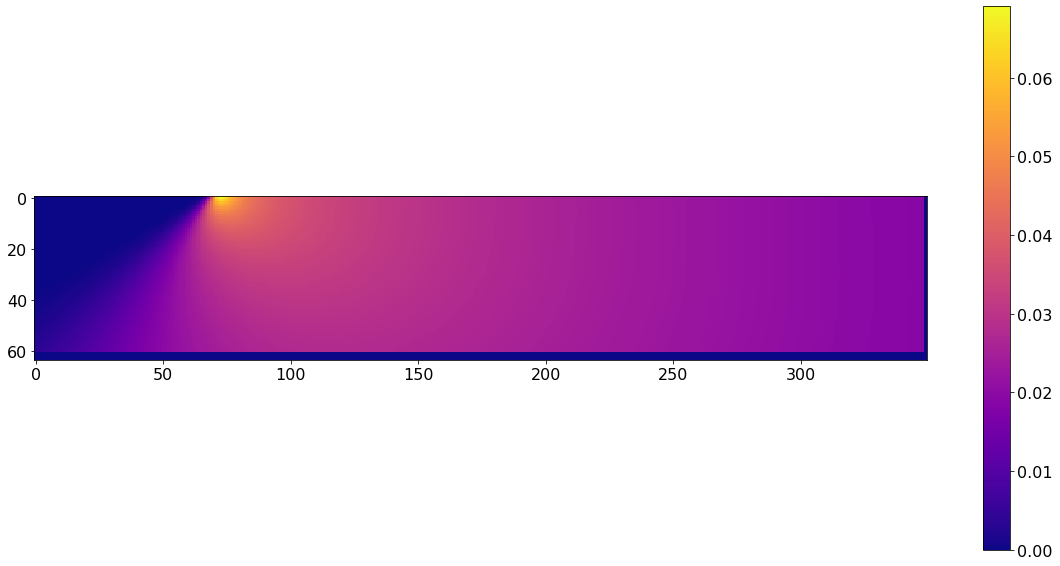

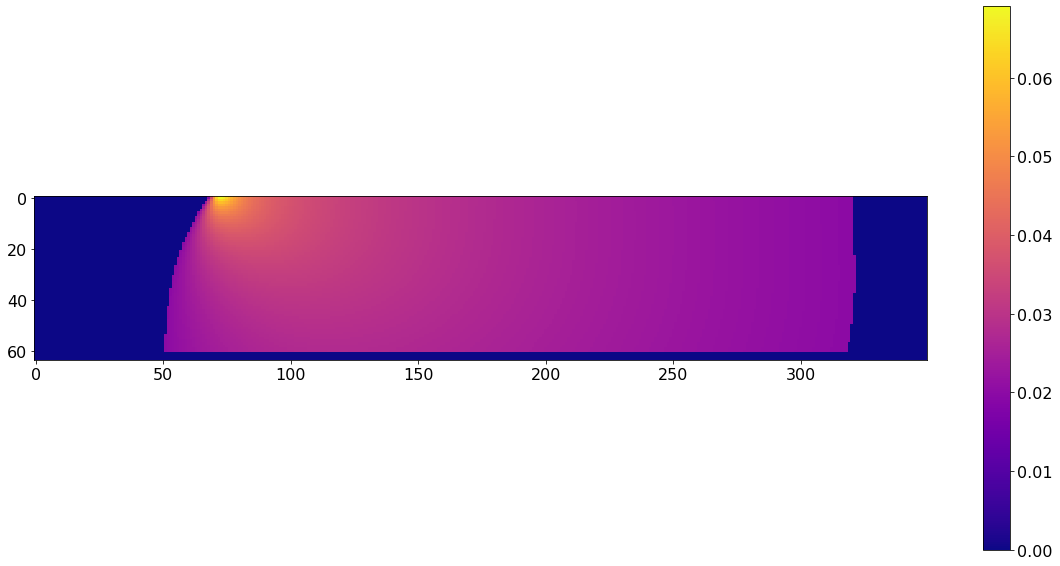

In [336]:
plt.figure(figsize=(20,10))
plt.imshow(gradient_r[:,:,0].T)
plt.colorbar()
plt.show()

threshold = 0.02
large_g = gradient_r.copy()
large_g[large_g < threshold] = 0

plt.figure(figsize=(20,10))
plt.imshow(large_g[:,:,0].T)
plt.colorbar()
plt.show()